**Ejercicio 1 — Carga y exploración inicial (Pandas)**

Carga un archivo CSV llamado mediciones_industriales.csv que contiene 8.000
registros y las columnas:
ID , Presion , Caudal , Vibracion , Estado .
1. Muestra las primeras 7 filas del DataFrame.
2. Muestra el tipo de datos de cada columna.
3. Indica cuántos valores nulos hay por columna.

In [1]:
import numpy as np
import matplotlib as mp
import matplotlib.pyplot as plt
import pandas as pd

mediciones = pd.read_csv("mediciones_industriales.csv")

print(mediciones,"\n")
print("Tipo del objeto mediciones: ",type(mediciones))
print("Tipo columna Presion: ",mediciones.Presion.dtype)
print("Tipo columna Caudal: ",mediciones.Caudal.dtype)
print("Tipo columna Vibracion: ",mediciones.Vibracion.dtype)
print("Tipo columna Estado: ",mediciones.Estado.dtype)

print("\nConteo de nulos\n",mediciones.isnull().sum())

        ID  Presion  Caudal  Vibracion  Estado
0        1   103.07   75.91       6.47  Normal
1        2    92.17   25.59       7.16  Normal
2        3    91.95   42.66       6.38  Normal
3        4    98.35   76.93       2.94  Normal
4        5   105.28   23.34       4.17  Normal
...    ...      ...     ...        ...     ...
7995  7996    88.90   46.23       5.31  Normal
7996  7997    96.56   68.16       5.76  Normal
7997  7998   107.66   31.41       4.89  Normal
7998  7999    93.15   52.49       8.59  Normal
7999  8000    86.58   47.66       5.32  Normal

[8000 rows x 5 columns] 

Tipo del objeto mediciones:  <class 'pandas.core.frame.DataFrame'>
Tipo columna Presion:  float64
Tipo columna Caudal:  float64
Tipo columna Vibracion:  float64
Tipo columna Estado:  object

Conteo de nulos
 ID           0
Presion      0
Caudal       0
Vibracion    0
Estado       0
dtype: int64


**Ejercicio 2 — Creación de Series y detección denulos**

Crea una Serie con los valores:
[101.2, 98.7, NaN, 105.3, 100.1]
y el índice:
["A", "B", "C", "D", "E"]
1. Muestra la serie completa.
2. Usa pd.isna() y pd.notna() para identificar valores faltantes.
3. Asigna un nombre a la serie y al índice.

In [2]:
serie1 = pd.Series([101.2, 98.7, None, 105.3, 100.1],index=["A", "B", "C", "D", "E"])
print("\nisna: \n",pd.isna(serie1))
print("\nnotna: \n",pd.notna(serie1))
serie1.name="Serie_1"
serie1.index.name = "Indice Serie_1"
print("\n",serie1)


isna: 
 A    False
B    False
C     True
D    False
E    False
dtype: bool

notna: 
 A     True
B     True
C    False
D     True
E     True
dtype: bool

 Indice Serie_1
A    101.2
B     98.7
C      NaN
D    105.3
E    100.1
Name: Serie_1, dtype: float64


**Ejercicio 3 — Construcción de DataFrame desde**

diccionarios
Crea un DataFrame a partir del siguiente diccionario anidado:
produccion = { "Planta_A": {2020: 1200, 2021: 1350, 2022: 1400}, "Planta_B": {2020:900, 2021:1100, 2022:1150}}
1. Muestra el DataFrame.
2. Añade una columna "Diferencia" = Planta_A - Planta_B.
3. Indica si el índice del DataFrame es único.

In [3]:
produccion = { "Planta_A": {2020: 1200, 2021: 1350, 2022: 1400}, "Planta_B": {2020:900, 2021:1100, 2022:1150}}
dtframe1 = pd.DataFrame(produccion)

print(dtframe1)

dtframe1["Diferencia"] = dtframe1["Planta_A"] - dtframe1["Planta_B"]

print("\n",dtframe1)



      Planta_A  Planta_B
2020      1200       900
2021      1350      1100
2022      1400      1150

       Planta_A  Planta_B  Diferencia
2020      1200       900         300
2021      1350      1100         250
2022      1400      1150         250


**Ejercicio 4 — Estadística descriptiva con NumPy**

1/3Dado el siguiente array:
vibracion = np.random.normal(5, 1.2, 5000)
1. Calcula media, mediana, varianza y desviación estándar.
2. Calcula los percentiles 10, 50 y 90.
3. Explica si la distribución parece simétrica o asimétrica.

In [4]:
vibracion = np.random.normal(5, 1.2, 5000)
# print(vibracion)
serie1 = pd.Series(vibracion)
dtframe1 = pd.DataFrame(serie1)
# print(dtframe1.describe())
print("Media: ",dtframe1.mean())
print("Mediana: ",dtframe1.median())
print("Varianza: ",dtframe1.var())
print("Desviación: ",dtframe1.std())
print("P10: ",dtframe1.quantile(0.1))
print("P50: ",dtframe1.quantile(0.5))
print("P90: ",dtframe1.quantile(0.9))

Media:  0    5.026221
dtype: float64
Mediana:  0    5.039992
dtype: float64
Varianza:  0    1.405964
dtype: float64
Desviación:  0    1.185734
dtype: float64
P10:  0    3.495948
Name: 0.1, dtype: float64
P50:  0    5.039992
Name: 0.5, dtype: float64
P90:  0    6.558768
Name: 0.9, dtype: float64


Media:  0    5.003397
Mediana:  0    5.021604
Varianza:  0    1.427036
Desviación:  0    1.194586
P10:  0    3.46537
P50:  0    5.021604
P90:  0    6.544027

Si es simétrica porque se ve que la distancia del p10 y p90 es similar, 1,5 aprox. 

** Ejercicio 5 — Clasificación vectorizada (np.where + Pandas)**

Usando la columna "Caudal" del DataFrame del ejercicio 1:
Clasifica cada registro en un nuevo array caudal_clasificado :
< 20 → categoría 1
20–50 → categoría 2
> 50 → categoría 3
1. Crea el array usando np.where .
2. Añádelo como columna al DataFrame.
3. Cuenta cuántos registros hay en cada categoría.

In [5]:
# cat1 = mediciones.Caudal < 20
# cat2 = (mediciones.Caudal >= 20) & (mediciones.Caudal <= 50)
aux = np.empty(mediciones.Caudal.count())
aux = np.where(mediciones.Caudal < 20, "Categoria 1",np.where((mediciones.Caudal >= 20)&(mediciones.Caudal < 50),"Categoria 2",""))
mediciones["Categoria"] = aux
# print(mediciones)
print("->",mediciones.Categoria.value_counts().reindex(["Categoria 1", "Categoria 2", ""]))

-> Categoria
Categoria 1    1610
Categoria 2    3266
               3124
Name: count, dtype: int64


**Ejercicio 6 — Slicing y fancy indexing**

Usando la columna "Estado" del DataFrame:
1. Obtén un array desde el índice 200 al 800 tomando uno de cada 15.
2. Selecciona mediante fancy indexing los índices [10, 100, 1000, 3000] .
3. Usa indexación booleana para contar cuántos estados son "Crítico" .

In [6]:
# print("1\n",mediciones.Estado[200:800:15])
# print("2\n",mediciones.Estado[[10, 100, 1000, 3000]])
print(mediciones.Estado[mediciones.Estado == "Crítico"].count())


776


**Ejercicio 7 — Gráfico de líneas (Matplotlib + Pandas)**

Representa la evolución del Caudal en los primeros 300 registros:

Línea roja

Grosor 2

Título y etiquetas de ejes

Cuadrícula activada

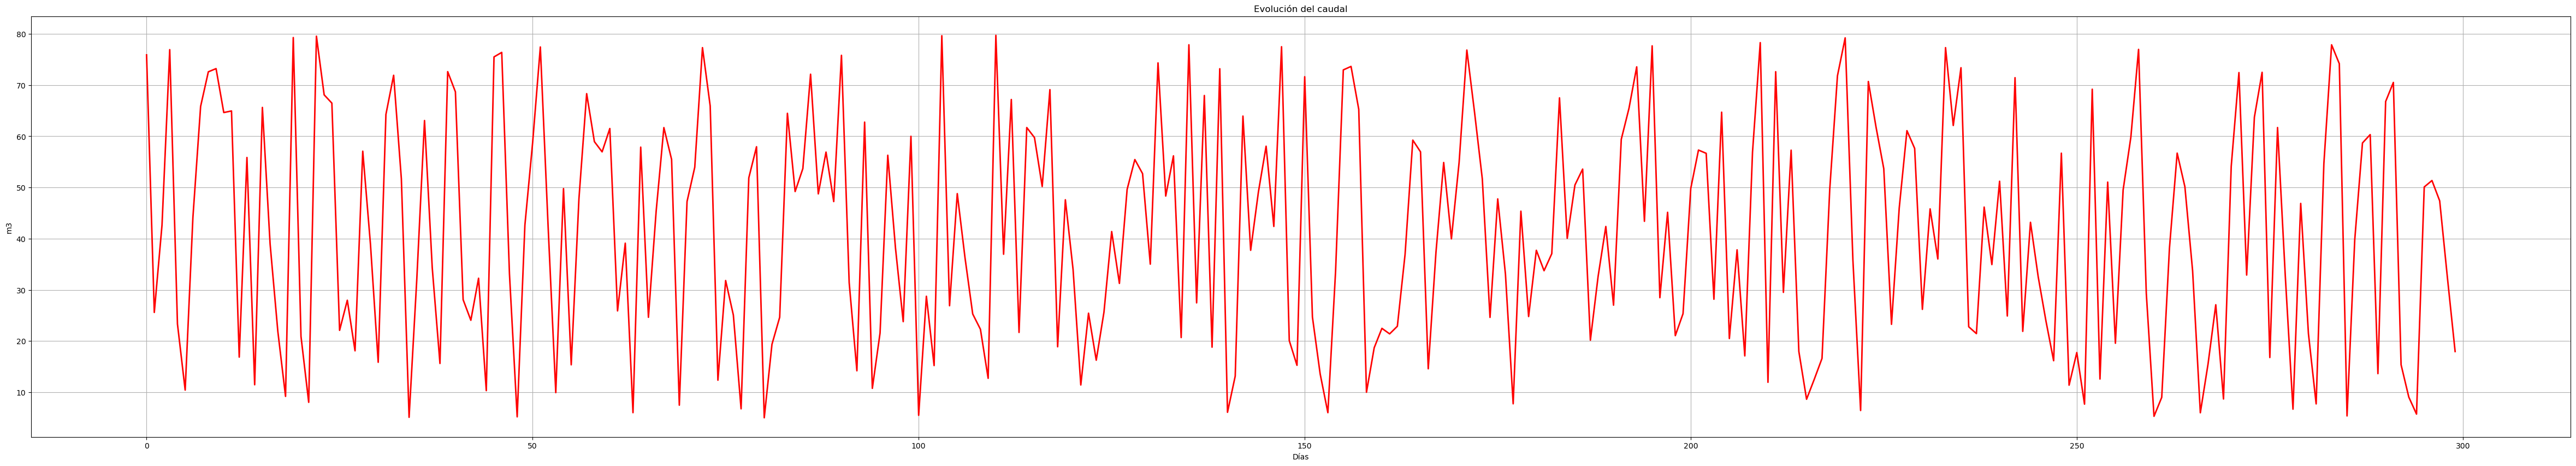

In [7]:
plt.figure(figsize=(60,10)) # ancho, alto
plt.plot(mediciones.Caudal[0:300],color="red",linewidth=2)
plt.xlabel("Días")
plt.ylabel("m3")
plt.title("Evolución del caudal")
plt.grid(visible=True)


**Ejercicio 8 — Histograma y análisis**
Crea un histograma de la columna "Presion" con bins = 8 .
1. Añade título y etiquetas.
2. Calcula media, mediana, desviación estándar, percentil 25 y 75.
3. Explica si el histograma coincide con los valores estadísticos.

count    8000.000000
mean       42.046660
std        21.555546
min         5.000000
25%        23.415000
50%        41.690000
75%        60.580000
max        79.990000
Name: Caudal, dtype: float64


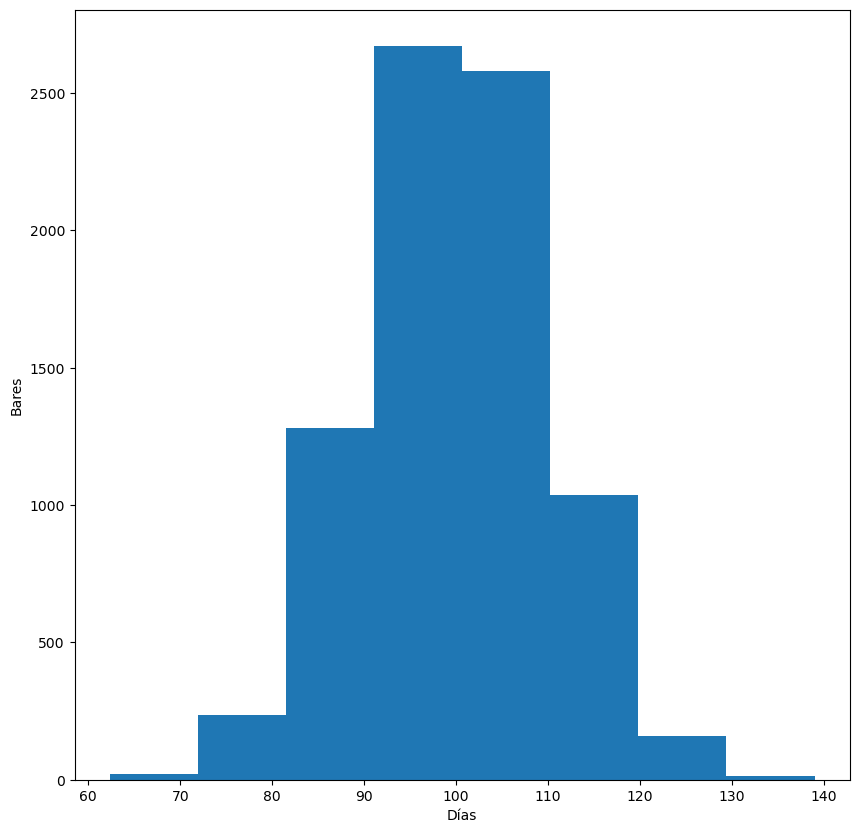

In [8]:
plt.figure(figsize=(10,10)) # ancho, alto
plt.hist(mediciones.Presion,bins=8)
plt.xlabel("Días")
plt.ylabel("Bares")
print(mediciones.Caudal.describe())

**Ejercicio 9 — Scatter plot multivariable**  
Representa un scatter plot con:  
Eje X → Presion  
Eje Y → Vibracion  
Color → Estado  
Solo los primeros 50 registros  
Colormap "plasma"

-> ['Normal' 'Crítico' 'Precaución']


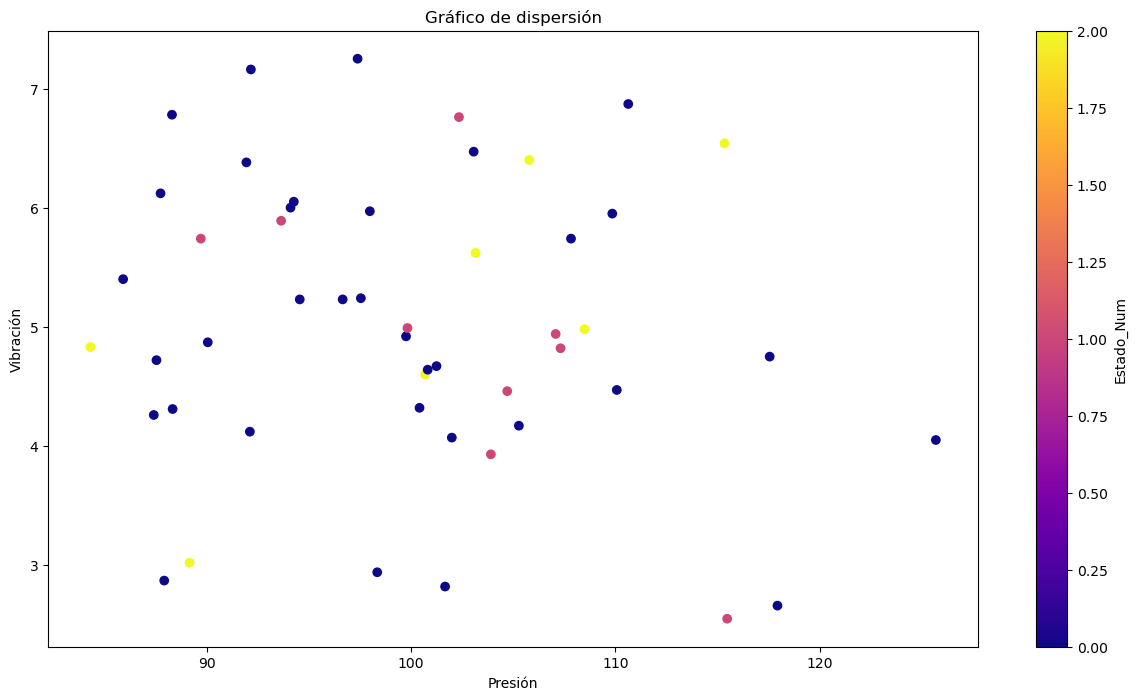

In [9]:
print("->",mediciones.Estado.unique()) # -> Devuelve todos los valores posibles que hay en la serie -> ['Normal' 'Crítico' 'Precaución']
mediciones["Estado_Num"] = np.where(mediciones.Estado == "Normal",0,np.where(mediciones.Estado == "Precaución", 1, 2)) # Normal - 0 | Precaución - 1 | Crítico - 2
# print("Normal -> ",mediciones.Estado.)
plt.figure(figsize=(15,8))
plt.scatter(mediciones.Presion[0:50],mediciones.Vibracion[0:50],c=mediciones.Estado_Num[0:50],cmap="plasma") # -> Preguntar a Elena
# plt.scatter(mediciones.Presion[0:50],mediciones.Vibracion[0:50])
plt.xlabel("Presión")
plt.ylabel("Vibración")
plt.title("Gráfico de dispersión")
plt.colorbar(label="Estado_Num")
plt.show()


**Ejercicio 10 — Manipulación avanzada de DataFrames**  
Usando el DataFrame del ejercicio 1:  
1. Crea una columna "Presion_normalizada" aplicando:  
(x - min) / (max - min)  
2. Elimina la columna "Estado".  
3. Reordena las columnas para que "ID" sea la primera.  
4. Convierte el DataFrame final a un array NumPy con .to_numpy()

In [ ]:
# mediciones.columns.get_loc("Estado") # Con esto obtenemos la posición de la columna -> no hace falta, pero lo dejo de apunte
# mediciones = mediciones.drop(columns="Estado")
# display(mediciones)

aux = list(mediciones.axes[1])
aux = aux[-1::-1]
print(aux)
mediciones = mediciones.reindex(aux,axis=1)
display(mediciones)

np_array = mediciones.to_numpy()
display(np_array) 


['Estado_Num', 'Categoria', 'Estado', 'Vibracion', 'Caudal', 'Presion', 'ID']


,Estado_Num,Categoria,Estado,Vibracion,Caudal,Presion,ID
0,0,,Normal,6.47,75.91,103.07,1
1,0,Categoria 2,Normal,7.16,25.59,92.17,2
2,0,Categoria 2,Normal,6.38,42.66,91.95,3
3,0,,Normal,2.94,76.93,98.35,4
4,0,Categoria 2,Normal,4.17,23.34,105.28,5
...,...,...,...,...,...,...,...
7995,0,Categoria 2,Normal,5.31,46.23,88.90,7996
7996,0,,Normal,5.76,68.16,96.56,7997
7997,0,Categoria 2,Normal,4.89,31.41,107.66,7998
7998,0,,Normal,8.59,52.49,93.15,7999


array([[0, '', 'Normal', ..., 75.91, 103.07, 1],
       [0, 'Categoria 2', 'Normal', ..., 25.59, 92.17, 2],
       [0, 'Categoria 2', 'Normal', ..., 42.66, 91.95, 3],
       ...,
       [0, 'Categoria 2', 'Normal', ..., 31.41, 107.66, 7998],
       [0, '', 'Normal', ..., 52.49, 93.15, 7999],
       [0, 'Categoria 2', 'Normal', ..., 47.66, 86.58, 8000]],
      dtype=object)